# Calibrum — Native Backtest

Notebook chuẩn để kiểm tra và trình bày Calibrum bằng đúng Native SDK:

```text
DMManager.get_data() / paperTrade.check_overfit()
        → CalibrumAlpha.generate()
        → AlphaBase.backtest(fee=0.4)
        → Get_metrics() / Plot_PNL()
```

Notebook không tự tính PnL, Sharpe, drawdown hoặc phí. OOS 2023–2024 và forward 2025+ được trình bày trước; IS chỉ nằm trong verifier kỹ thuật của package.


In [1]:
# 1. Runtime Native SDK
import hashlib
import json
import os
from pathlib import Path
import sys
import time

import pandas as pd
from IPython.display import display
from dotenv import load_dotenv

%matplotlib inline
load_dotenv('/home/jovyan/shared-storage/libs/.env')

profile = os.environ.get('EVANGELION_PROFILE', 'research').lower()
if profile != 'research':
    raise RuntimeError(f'Notebook cần Research profile, nhận {profile!r}')

import loadlibs  # noqa: F401
import alpha_base
from alpha_base import AlphaBase
from dm_manager import DMManager

ROOT = Path(os.environ.get('WORKSPACE_ROOT', ''))
if not (ROOT / 'alphas' / 'PS_V30_Vien_Calibrum').exists():
    if (Path.cwd() / 'alphas' / 'PS_V30_Vien_Calibrum').exists():
        ROOT = Path.cwd()
    elif Path('/workspaces').exists():
        for p in Path('/workspaces').iterdir():
            if (p / 'alphas' / 'PS_V30_Vien_Calibrum').exists():
                ROOT = p
                break
if not ROOT.exists():
    ROOT = Path.cwd()
ALPHA_DIR = ROOT / 'alphas' / 'PS_V30_Vien_Calibrum'
if str(ALPHA_DIR) not in sys.path:
    sys.path.insert(0, str(ALPHA_DIR))

from PS_V30_Vien_Calibrum import CalibrumAlpha

print('Python executable :', sys.executable)
print('Runtime profile   :', profile)
print('Alpha class       :', CalibrumAlpha.__name__)
print('AlphaBase subclass:', issubclass(CalibrumAlpha, AlphaBase))


📦 Tìm thấy 9 modules (.so): alpha_base0.so, dm_manager.so, alpha_base.so, dm_base.so, utils.so, alpha_repo.so, postgres_db.so, log_k8s.so, live_dm.so
--- Local Mode: Logging to logs/master01.log ---


Python executable : /opt/conda/bin/python
Runtime profile   : research
Alpha class       : CalibrumAlpha
AlphaBase subclass: True


In [2]:
# 2. Config và submission manifest
CONFIG_PATH = ALPHA_DIR / 'config.json'
MANIFEST_PATH = ALPHA_DIR / 'submit_manifest.json'
FEE = 0.4

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
config['working_path'] = str(ALPHA_DIR)
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))

def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

missing = [name for name in manifest['submission_files'] if not (ALPHA_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f'Manifest thiếu file: {missing}')
expected_files = ['PS_V30_Vien_Calibrum.py', 'config.json', 'PS_V30_Vien_Calibrum_model.pt']
if manifest['submission_files'] != expected_files:
    raise RuntimeError('Submission manifest Calibrum không đúng contract ba file')

print('Alpha name :', config['name'])
print('Alpha type :', config['alpha_type'])
print('Source SHA :', sha256(ALPHA_DIR / 'PS_V30_Vien_Calibrum.py'))
print('Config SHA :', sha256(CONFIG_PATH))
print('Model SHA  :', sha256(ALPHA_DIR / config['parameters']['model_file']))
print('Files      :', manifest['submission_files'])
print('Feeds      :', [f"{x['ticker']}/{x['timeframe']}" for x in config['data']])


Alpha name : PS_V30_Vien_Calibrum
Alpha type : ml
Source SHA : 0c653cfeaf21ffa9dd36eccab39200ccd526e7f18e05c91a020c392c99c38b33
Config SHA : 5a4adf846e9b33fea47ea62c6062fa092198e04736e8e1d008ca233b59ecf9ec
Model SHA  : f78440b77450e888b82068e185acbddabf7278f3ecff29757e5cfc85d255051f
Files      : ['PS_V30_Vien_Calibrum.py', 'config.json', 'PS_V30_Vien_Calibrum_model.pt']
Feeds      : ['vn30f1m/30m', 'vn30/30m']


## Nạp exact FIT stream từ SDK

`paperTrade.check_overfit()` là hàm có sẵn của SDK. Sau khi checker hoàn tất, notebook lấy chính `alpha_check_fit.dm_list` do SDK cung cấp để giữ đầy đủ warm-up cho các cửa sổ đánh giá.


In [3]:
# 3. Nạp native base stream rồi yêu cầu exact FIT stream
manager = DMManager('PM_alpha_calibrum_notebook')
base_dm_list = manager.get_data(config['data'])

probe = CalibrumAlpha(config)
probe.generate(base_dm_list)
probe.backtest(fee=FEE)

checker = alpha_base.paperTrade(probe, probe.dm_list, probe.domain_api)
overfit_pass = bool(checker.check_overfit())
if not overfit_pass:
    raise RuntimeError('Overfit Check không PASS')
fit_dm_list = checker.alpha_check_fit.dm_list

coverage = []
for dm in fit_dm_list:
    frame = dm.data
    dt_col = 'datetime' if 'datetime' in frame.columns else 'Datetime'
    timestamps = pd.to_datetime(frame[dt_col])
    coverage.append({
        'feed': f'{dm.ticker}/{dm.timeframe}',
        'rows': len(frame),
        'start': timestamps.min(),
        'end': timestamps.max(),
    })

print('Overfit Check:', overfit_pass)
display(pd.DataFrame(coverage))


Overfit Check: True


,feed,rows,start,end
0,vn30f1m/30m,22227,2017-08-10 09:00:00,2026-09-28 09:30:00
1,vn30/30m,29187,2014-08-04 09:00:00,2026-09-28 11:00:00


In [4]:
# 4. Sinh một lần toàn bộ position bằng chính CalibrumAlpha
started = time.perf_counter()
full_alpha = CalibrumAlpha(config)
full_signals = full_alpha.generate(fit_dm_list).copy()
generate_seconds = time.perf_counter() - started
full_signals['Datetime'] = pd.to_datetime(full_signals['Datetime'])

assert list(full_signals.columns) == ['Datetime', 'Close', 'Position']
assert not full_signals['Position'].isna().any()
assert full_signals['Position'].isin([-1, 0, 1]).all()

print(f'Generate: {generate_seconds:.3f}s / {len(full_signals):,} rows')
print('Range   :', full_signals['Datetime'].min(), '→', full_signals['Datetime'].max())
display(full_signals['Position'].value_counts().sort_index().rename('rows'))


Generate: 0.619s / 22,227 rows
Range   : 2017-08-10 09:00:00 → 2026-09-28 09:30:00


Position
-1     6509
 0     5384
 1    10334
Name: rows, dtype: int64

## OOS 2023–2024

Backtest, metrics và PnL curve đều do Native SDK tạo.


                   Margin: 15.38
         Margin after fee: 11.93
                      MDD: 83.4 (6.59%); Time: 2024-07-15 → 2024-07-30
   Total trading quantity: 308
         Sharpe after fee: 2.51
         Profit per trade: 2.77
             Total Profit: 1097.9
         Profit after fee: 851.9
 Trading quantity per day: 0.62
 Profit per day after fee: 1.72
          Return per year: 28.46
      Avg return per year: 33.38
          Profit per year: 416.08
                  HitRate: 47.73%
            Daily HitRate: 55.97%
           Weekly HitRate: 66.67%
          Monthly HitRate: 87.50%
                     Long: 173
                    Short: 135
             Hitrate long: 48.55%
            Hitrate short: 46.67%
Longest consecutive losing days: 10
        Overnight holding: 77.53%


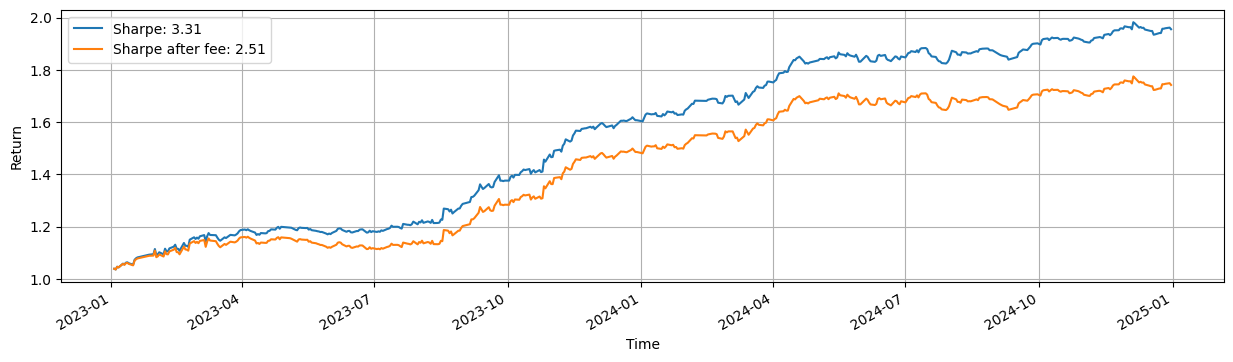

In [5]:
# 5. Native backtest — OOS 2023–2024
oos_mask = full_signals['Datetime'].between(
    pd.Timestamp('2023-01-01'),
    pd.Timestamp('2024-12-31 23:59:59'),
)
oos_alpha = CalibrumAlpha(config)
oos_alpha.alpha_df = full_signals.loc[oos_mask, ['Datetime', 'Close', 'Position']].reset_index(drop=True)
oos_bt = oos_alpha.backtest(fee=FEE)
oos_metrics = oos_bt.Get_metrics()
oos_bt.Plot_PNL()


## Forward 2025–24/09/2026

Ngày kết thúc được khóa để tái tạo đúng evaluation đã công bố; notebook không tự động đưa phiên mới vào kết quả frozen.


                   Margin: 18.1
         Margin after fee: 15.77
                      MDD: 217.6 (11.23%); Time: 2025-12-25 → 2026-01-21
   Total trading quantity: 284
         Sharpe after fee: 2.89
         Profit per trade: 5.4
             Total Profit: 1760.9
         Profit after fee: 1534.1
 Trading quantity per day: 0.67
 Profit per day after fee: 3.59
          Return per year: 42.33
      Avg return per year: 39.84
          Profit per year: 907.2
                  HitRate: 47.54%
            Daily HitRate: 56.49%
           Weekly HitRate: 73.03%
          Monthly HitRate: 85.71%
                     Long: 158
                    Short: 126
             Hitrate long: 48.73%
            Hitrate short: 46.03%
Longest consecutive losing days: 6
        Overnight holding: 75.41%


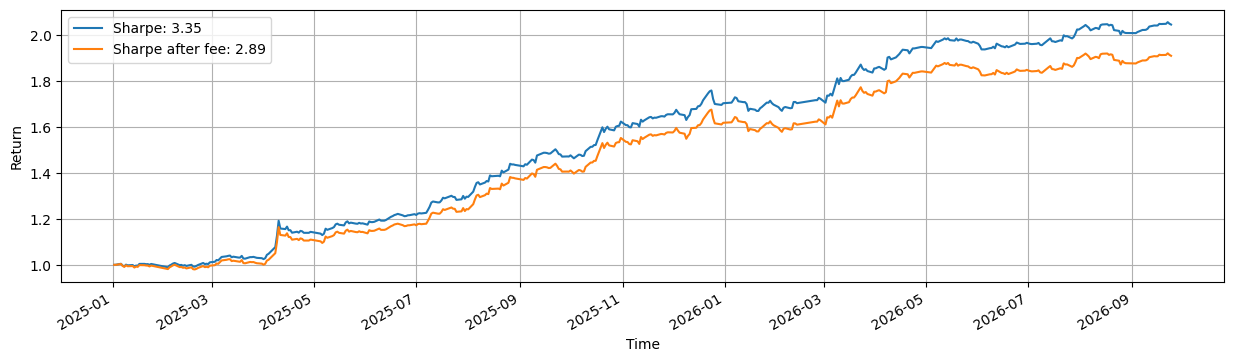

In [6]:
# 6. Native backtest — Forward 2025+
forward_mask = full_signals['Datetime'].between(
    pd.Timestamp('2025-01-01'),
    pd.Timestamp('2026-09-24 23:59:59'),
)
forward_alpha = CalibrumAlpha(config)
forward_alpha.alpha_df = full_signals.loc[forward_mask, ['Datetime', 'Close', 'Position']].reset_index(drop=True)
forward_bt = forward_alpha.backtest(fee=FEE)
forward_metrics = forward_bt.Get_metrics()
forward_bt.Plot_PNL()


## Full cycle 10/08/2017–24/09/2026


                   Margin: 19.6
         Margin after fee: 16.02
                      MDD: 217.6 (15.89%); Time: 2025-12-25 → 2026-01-21
   Total trading quantity: 1400
         Sharpe after fee: 2.68
         Profit per trade: 3.57
             Total Profit: 6121.7
         Profit after fee: 5002.1
 Trading quantity per day: 0.62
 Profit per day after fee: 2.2
          Return per year: 39.76
      Avg return per year: 38.55
          Profit per year: 555.05
                  HitRate: 48.71%
            Daily HitRate: 56.51%
           Weekly HitRate: 71.13%
          Monthly HitRate: 89.09%
                     Long: 751
                    Short: 649
             Hitrate long: 51.00%
            Hitrate short: 46.07%
Longest consecutive losing days: 10
        Overnight holding: 76.45%


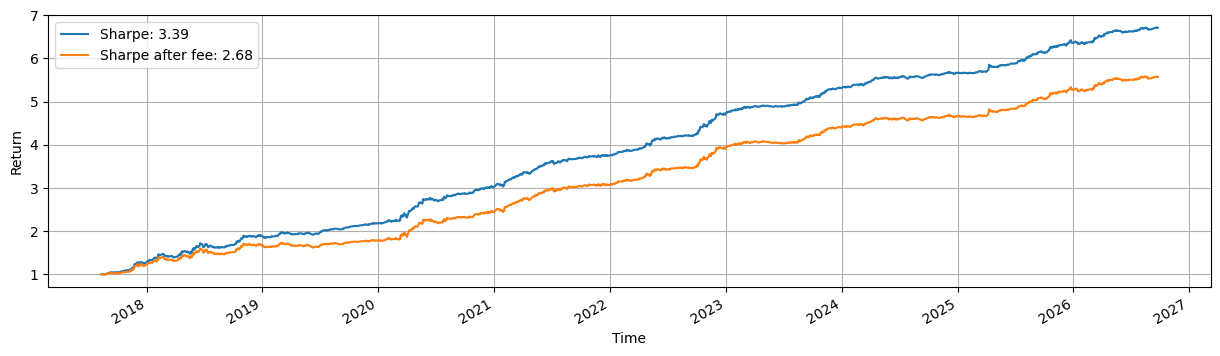

In [7]:
# 7. Native backtest — Full cycle
full_mask = full_signals['Datetime'].between(
    pd.Timestamp('2017-08-10'),
    pd.Timestamp('2026-09-24 23:59:59'),
)
cycle_alpha = CalibrumAlpha(config)
cycle_alpha.alpha_df = full_signals.loc[full_mask, ['Datetime', 'Close', 'Position']].reset_index(drop=True)
cycle_bt = cycle_alpha.backtest(fee=FEE)
cycle_metrics = cycle_bt.Get_metrics()
cycle_bt.Plot_PNL()


## So sánh native metrics

Bảng chỉ lấy các giá trị trả về trực tiếp từ `Get_metrics()`.


In [8]:
# 8. Tổng hợp trực tiếp từ native Get_metrics()
metric_names = [
    'profit_after_fee', 'sharpe_after_fee', 'margin_after_fee',
    'mdd_point', 'mdd', 'total_trade', 'hitrate', 'calmar',
]
native_summary = pd.DataFrame({
    'OOS 2023–2024': {key: oos_metrics.get(key) for key in metric_names},
    'Forward 2025+': {key: forward_metrics.get(key) for key in metric_names},
    'Full cycle': {key: cycle_metrics.get(key) for key in metric_names},
})
display(native_summary)


,OOS 2023–2024,Forward 2025+,Full cycle
profit_after_fee,851.90,1534.10,5002.10
sharpe_after_fee,2.51,2.89,2.68
margin_after_fee,11.93,15.77,16.02
mdd_point,83.40,217.60,217.60
mdd,6.59,11.23,15.89
total_trade,308.00,284.00,1400.00
hitrate,47.73,47.54,48.71
calmar,4.32,3.77,2.50


## Lưu ý

- Notebook không thuộc submission manifest và không submit/update Alpha.
- `check_overfit()` cần kết nối endpoint nội bộ.
- OOS/forward đã được mở trước đây; đây không còn là holdout để tuning.
- Mọi metrics và PnL curve đều do Native SDK tạo.
- Exact historical result không giải quyết partial-bar live parity tại lịch `:29:46/:59:46`.
